In [15]:
import pandas as pd
import numpy as np 
import scipy.stats as st
import matplotlib.pyplot as plt 
import seaborn as sns 

np.random.seed(42)


Task 1: One sample t test


In [16]:
#generating data 
wait_times = np.random.normal(loc=4.3, scale = 1.2, size = 35)
wait_times

array([4.89605698, 4.13408284, 5.07722625, 6.12763583, 4.01901595,
       4.01903565, 6.19505538, 5.22092167, 3.73663074, 4.95107205,
       3.74389877, 3.7411243 , 4.59035473, 2.00406371, 2.2300986 ,
       3.62525496, 3.08460266, 4.6770968 , 3.21037111, 2.60523556,
       6.05877852, 4.02906844, 4.38103385, 2.59030218, 3.64674073,
       4.43310711, 2.91880771, 4.75083762, 3.57923357, 3.9499675 ,
       3.57795207, 6.52273382, 4.28380333, 3.03074689, 5.28705389])

Our hypotheses
H0 --- mean = 4
by default average wait time is 4 

H1 --- mean != 4

average wait time differs from 4

In [17]:
t_stat, p_val = st.ttest_1samp(wait_times, popmean=4.0)
t_stat, p_val

(np.float64(0.7450545455494864), np.float64(0.46135826637733657))

In [18]:
#Decision

alpha = 0.5

if p_val < alpha:
    print('Reject H0')
else:
    print("Fail to reject H0")    

Reject H0


There is sufficient evidence that the average wait time differs from 4 minutes.

Task 2: Independent Two-Sample t-Test

In [19]:
#data generate
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)

State Hypotheses
H0: mean_a = mean_b
H1: mean_a != mean_b

In [20]:
#Compute variance of each group
var_a = np.var(group_a, ddof=1)
var_b = np.var(group_b, ddof=1)
var_a, var_b

(np.float64(136.0601078603523), np.float64(169.25371691194957))

In [21]:
levene_stat, levene_p = st.levene(group_a, group_b)

levene_stat, levene_p

(np.float64(0.1394706424159864), np.float64(0.7096144854457804))

In [22]:
if levene_p > 0.05:
    equal_var = True
else:
    equal_var = False

In [23]:
t_stat, p_val = st.ttest_ind(group_a, group_b, equal_var=equal_var)

t_stat, p_val

(np.float64(-2.26051641411263), np.float64(0.026001356171491255))

In [ ]:
if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0") 

Reject H0


There is sufficient evidence that the two group means are different.

Task 3: Paired t-Test

In [25]:
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)

H0: diff = 0
H1: diff ≠ 0

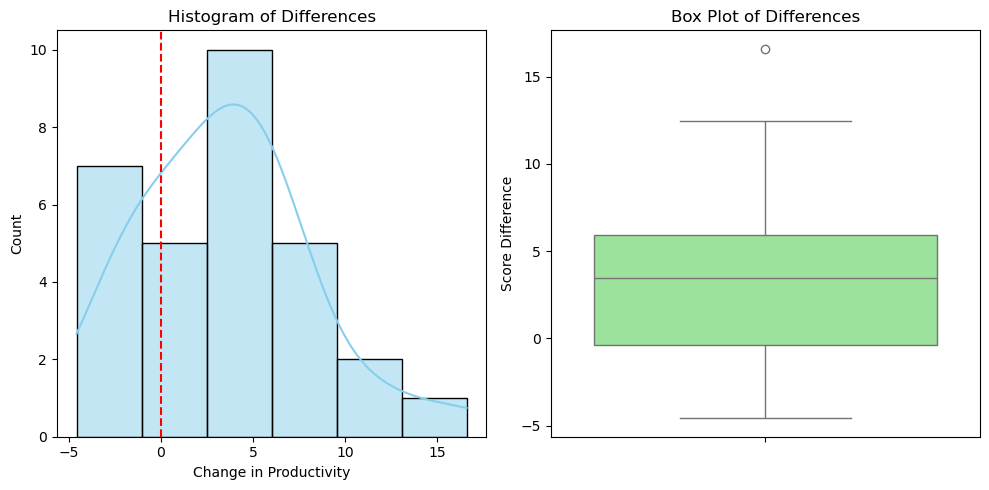

t-statistic: 4.0792
p-value: 3.2255e-04


In [28]:
# Compute differences
differences = after - before

# Brief Inspection: Visualization
plt.figure(figsize=(10, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(differences, kde=True, color='skyblue')
plt.axvline(0, color='red', linestyle='--')
plt.title('Histogram of Differences')
plt.xlabel('Change in Productivity')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=differences, color='lightgreen')
plt.title('Box Plot of Differences')
plt.ylabel('Score Difference')

plt.tight_layout()
plt.show()

# Run Paired t-Test
t_stat, p_val = st.ttest_rel(after, before)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4e}")